# Python script for recreating Augenstreich et al. data analysis

Nativelty in Python rather than using Python bindings for ImageJ. Also uses newest CellPose SAM

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from cellpose import models, io

from skimage import io as skio
from skimage.color import label2rgb
from skimage.transform import rescale, resize
from skimage import measure, filters, color, exposure

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

io.logger_setup()

2026-03-22 19:49:13,219 [INFO] WRITING LOG OUTPUT TO /Users/twh/.cellpose/run.log
2026-03-22 19:49:13,219 [INFO] 
cellpose version: 	4.0.9 
platform:       	darwin 
python version: 	3.13.0 
torch version:  	2.10.0


(<Logger cellpose.io (INFO)>, PosixPath('/Users/twh/.cellpose/run.log'))

## Loading file

In [3]:
directory_path = Path("/Users/twh/Downloads")
filename = "ULK101_1 uM_4.tif"

out = directory_path / "Output"
out.mkdir(exist_ok=True)

In [4]:
image_data = skio.imread(directory_path / filename)

# Shape should be (Z, C, Y, X).
print(f"Original image shape: {image_data.shape}")

Original image shape: (22, 1024, 1024, 4)


## Z-stack maximum intensity projection

In [5]:
mip_image = np.max(image_data, axis=0)  # MIP

print(f"Flattened image shape: {mip_image.shape} (Expected: X, Y, C)")

# Extract the channels (C is the last dimension, so we slice the 3rd axis)
channel_dapi = mip_image[:, :, 0]
channel_lc3 = mip_image[:, :, 1]
channel_brightfield = mip_image[:, :, 2]
channel_mav = mip_image[:, :, 3]

Flattened image shape: (1024, 1024, 4) (Expected: X, Y, C)


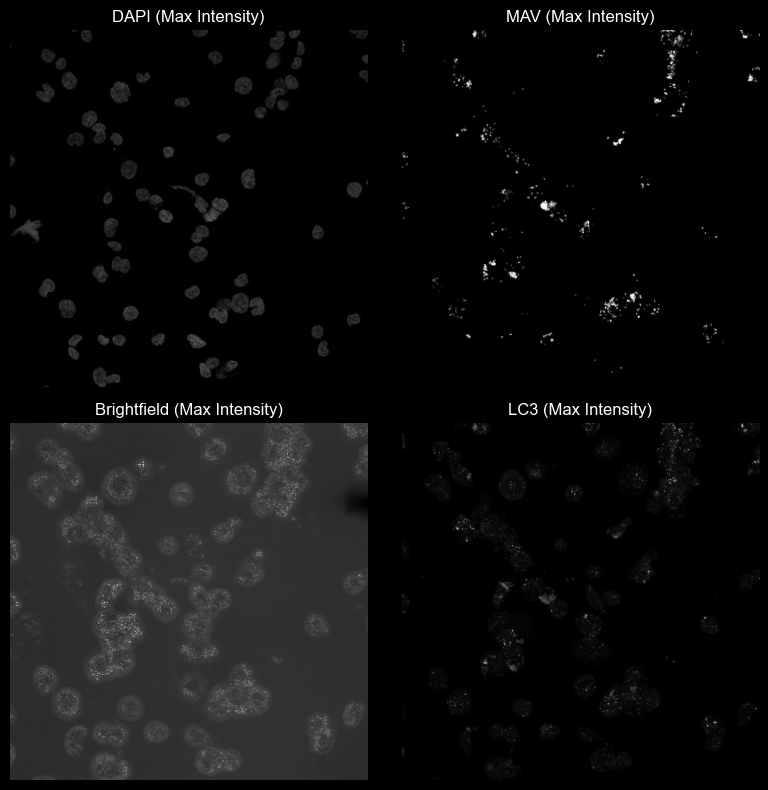

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.ravel()

# DAPI
ax[0].imshow(channel_dapi, cmap="gray")
ax[0].set_title("DAPI (Max Intensity)")
ax[0].axis("off")

# MAV
ax[1].imshow(channel_mav, cmap="gray")
ax[1].set_title("MAV (Max Intensity)")
ax[1].axis("off")

# Brightfield
ax[2].imshow(channel_brightfield, cmap="gray")
ax[2].set_title("Brightfield (Max Intensity)")
ax[2].axis("off")

# LC3
ax[3].imshow(channel_lc3, cmap="gray")
ax[3].set_title("LC3 (Max Intensity)")
ax[3].axis("off")

plt.tight_layout()

## Cell detection

In [7]:
enhance_contrast = True
do_downsample = True
scale_factor = (
    0.25  # 0.5 means the image will be scaled to 50% of its original width and height
)

bf_image_for_seg = np.dstack([channel_brightfield, channel_dapi])

if enhance_contrast:
    bf_image_for_seg = exposure.equalize_adapthist(bf_image_for_seg, clip_limit=0.03)

if do_downsample:
    bf_image_for_seg = rescale(bf_image_for_seg, scale_factor, anti_aliasing=True)
    print(
        f"Downsampled image for Cellpose from {channel_brightfield.shape} to {bf_image_for_seg.shape}"
    )

model = models.CellposeModel(gpu=True)
masks, flows, styles = model.eval(bf_image_for_seg, diameter=None, resample=False)


if do_downsample:
    masks = resize(
        masks,
        channel_brightfield.shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    ).astype(int)

Downsampled image for Cellpose from (1024, 1024) to (256, 256, 1)
2026-03-22 19:49:13,991 [INFO] ** TORCH MPS version installed and working. **
2026-03-22 19:49:13,991 [INFO] >>>> using GPU (MPS)
2026-03-22 19:49:15,582 [INFO] >>>> loading model /Users/twh/.cellpose/models/cpsam


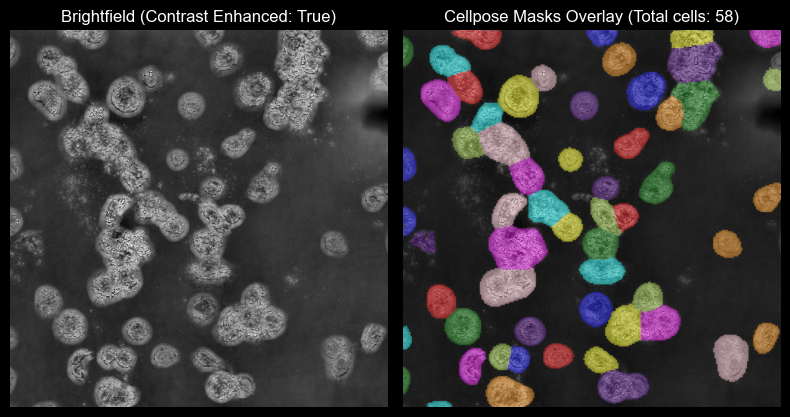

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

# Display the original (or enhanced) brightfield image at full resolution
display_img = (
    exposure.equalize_adapthist(channel_brightfield, clip_limit=0.03)
    if enhance_contrast
    else channel_brightfield
)

axes[0].imshow(display_img, cmap="gray")
axes[0].set_title(f"Brightfield (Contrast Enhanced: {enhance_contrast})")
axes[0].axis("off")

# Display the full-resolution masks overlaid on the full-resolution image
mask_overlay = label2rgb(masks, bg_label=0)
axes[1].imshow(display_img, cmap="gray")
axes[1].imshow(mask_overlay, alpha=0.4)
axes[1].set_title(f"Cellpose Masks Overlay (Total cells: {masks.max()})")
axes[1].axis("off")

plt.tight_layout()

## MAV cluster detection

In [9]:
min_blob_size = 10  # Minimum area in pixels
max_blob_size = 500  # Maximum area in pixels
filter_by_cell_mask = True  # Toggle to completely drop blobs outside cells

thresh_mav = filters.threshold_otsu(channel_mav)
binary_mav = channel_mav > thresh_mav

labeled_mav = measure.label(binary_mav)

cell_mask_bool = masks > 0


overlapping_labels = np.unique(labeled_mav * cell_mask_bool)

overlapping_labels = np.setdiff1d(overlapping_labels, [0])

valid_blobs_mask = np.zeros_like(labeled_mav, dtype=bool)

centroids_in_x, centroids_in_y = [], []
centroids_out_x, centroids_out_y = [], []

for prop in measure.regionprops(labeled_mav):
    if min_blob_size <= prop.area <= max_blob_size:
        is_overlapping = prop.label in overlapping_labels
        y, x = prop.centroid

        if is_overlapping:
            centroids_in_y.append(y)
            centroids_in_x.append(x)

            valid_blobs_mask[labeled_mav == prop.label] = True
        else:
            centroids_out_y.append(y)
            centroids_out_x.append(x)

            if not filter_by_cell_mask:
                valid_blobs_mask[labeled_mav == prop.label] = True

filtered_labeled_mav = measure.label(valid_blobs_mask)

print(f"Total valid size blobs: {len(centroids_in_x) + len(centroids_out_x)}")
print(f"  - Overlapping cells (Blue): {len(centroids_in_x)}")
print(f"  - Outside cells (Red): {len(centroids_out_x)}")

Total valid size blobs: 181
  - Overlapping cells (Blue): 180
  - Outside cells (Red): 1


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

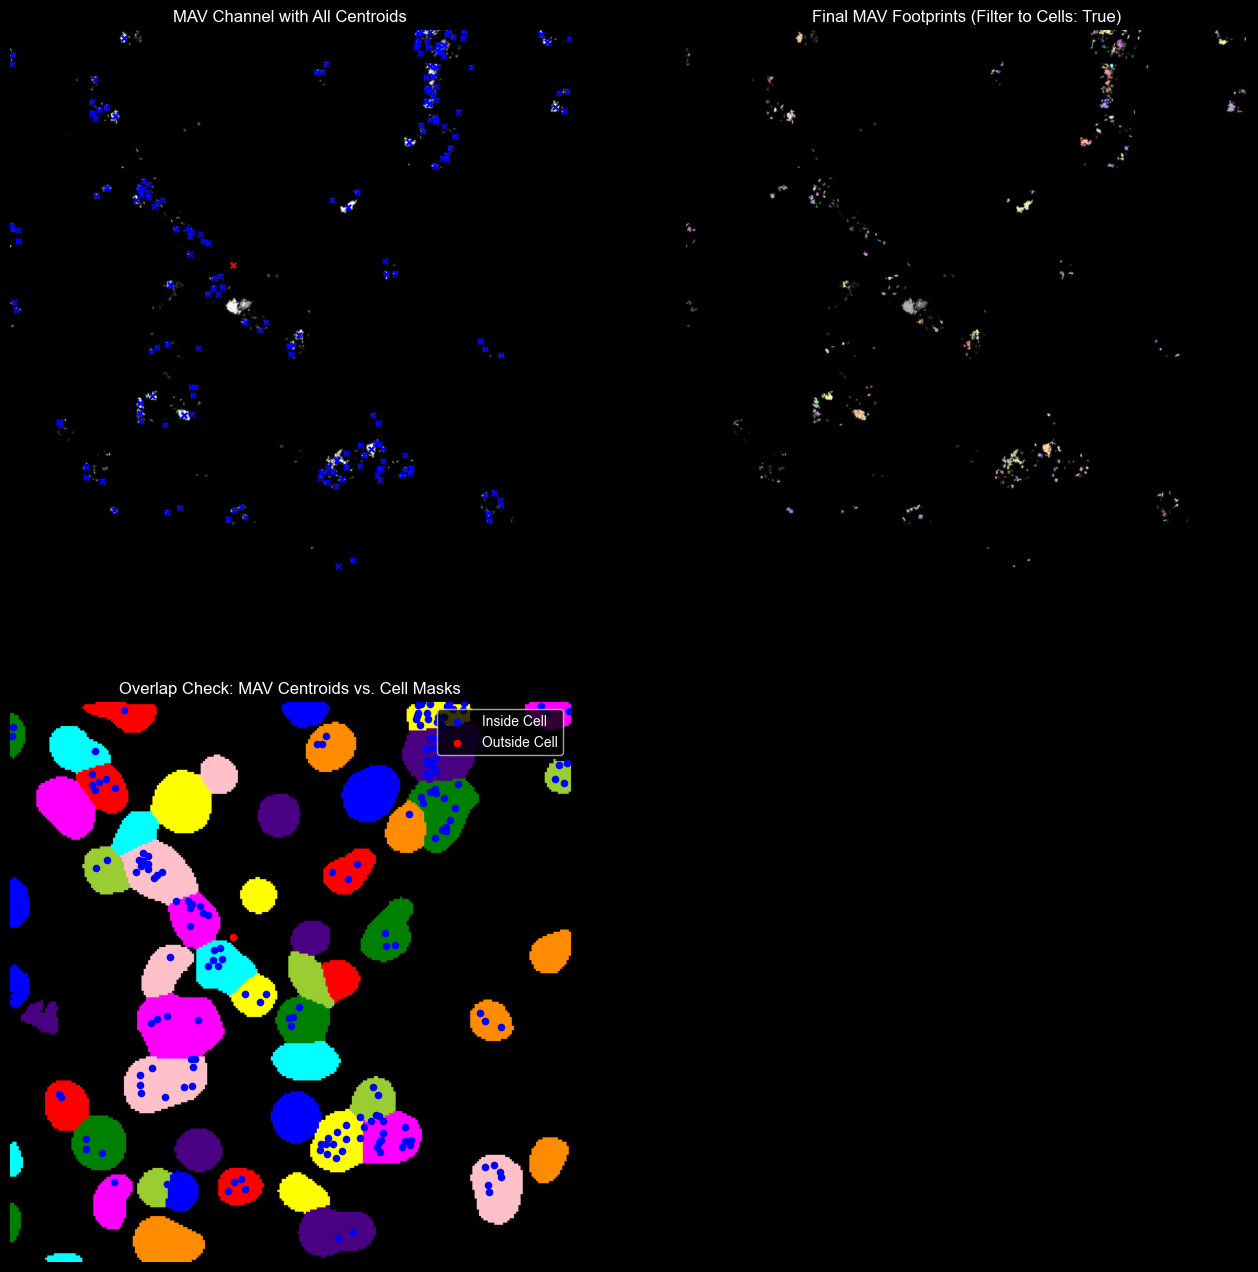

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Plot 1: Original MAV with all valid centroids
axes[0, 0].imshow(channel_mav, cmap="gray")
axes[0, 0].scatter(centroids_in_x, centroids_in_y, color="blue", s=15, marker="x")
axes[0, 0].scatter(centroids_out_x, centroids_out_y, color="red", s=15, marker="x")
axes[0, 0].set_title("MAV Channel with All Centroids")
axes[0, 0].axis("off")

# Plot 2: Final Filtered Mask Overlay
# This shows exactly what is moving forward to the next step
overlay_mav = color.label2rgb(
    filtered_labeled_mav, image=channel_mav, bg_label=0, alpha=0.3
)
axes[0, 1].imshow(overlay_mav)
axes[0, 1].set_title(f"Final MAV Footprints (Filter to Cells: {filter_by_cell_mask})")
axes[0, 1].axis("off")

# Plot 3: Cell Boundaries and Red/Blue Overlap Check
# Display the brightfield image for context
bf_display = exposure.equalize_adapthist(channel_brightfield, clip_limit=0.03)
axes[1, 0].imshow(bf_display, cmap="gray")

# Overlay the cell masks faintly
cell_overlay = color.label2rgb(masks, bg_label=0, alpha=0.2)
axes[1, 0].imshow(cell_overlay)

# Plot the categorized centroids
axes[1, 0].scatter(
    centroids_in_x, centroids_in_y, color="blue", s=20, label="Inside Cell"
)
axes[1, 0].scatter(
    centroids_out_x, centroids_out_y, color="red", s=20, label="Outside Cell"
)
axes[1, 0].set_title("Overlap Check: MAV Centroids vs. Cell Masks")
axes[1, 0].legend(loc="upper right")
axes[1, 0].axis("off")

# Plot 4: Turn off the unused quadrant
axes[1, 1].axis("off")

In [11]:
R_max = 20  # Maximum radius to profile (in pixels)
step_size = 1  # Width of each annulus

x_coords = np.array(centroids_in_x)
y_coords = np.array(centroids_in_y)

pad_w = int(np.ceil(R_max))


padded_lc3 = np.pad(
    channel_lc3.astype(float), pad_w, mode="constant", constant_values=np.nan
)

valid_pixels_mask = ~np.isnan(padded_lc3)
data_clean = np.nan_to_num(padded_lc3, nan=0.0)

shifted_positions = list(zip(x_coords + pad_w, y_coords + pad_w))

M = len(shifted_positions)
radii = np.arange(step_size, R_max + step_size, step_size)
R = len(radii)

profile_matrix = np.zeros((M, R))

print(f"Calculating radial profiles for {M} blobs up to radius {R_max}...")
for i, r in enumerate(radii):
    # The first step is a central circle, subsequent steps are annuli
    if i == 0:
        apertures = CircularAperture(shifted_positions, r=r)
    else:
        apertures = CircularAnnulus(shifted_positions, r_in=radii[i - 1], r_out=r)

    phot_data = aperture_photometry(data_clean, apertures, method="exact")
    phot_area = aperture_photometry(
        valid_pixels_mask.astype(float), apertures, method="exact"
    )

    sum_val = phot_data["aperture_sum"].data
    area_val = phot_area["aperture_sum"].data

    mean_intensity = np.divide(
        sum_val, area_val, out=np.full_like(sum_val, np.nan), where=(area_val > 0)
    )

    profile_matrix[:, i] = mean_intensity

print(f"Profile matrix shape: {profile_matrix.shape} (M x R)")

Calculating radial profiles for 180 blobs up to radius 20...
Profile matrix shape: (180, 20) (M x R)


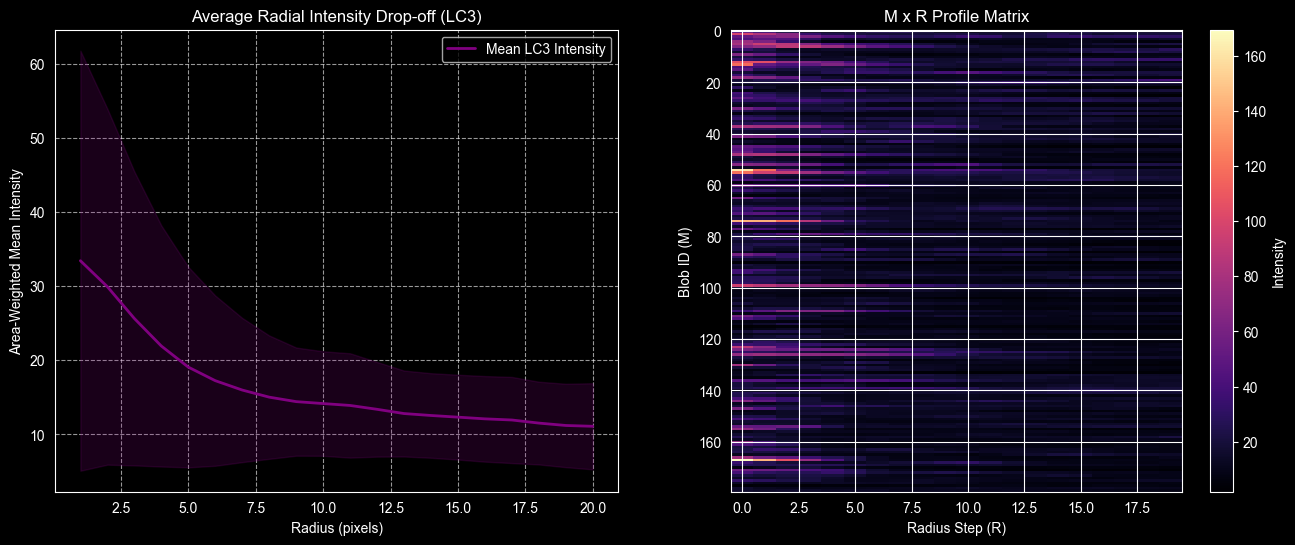

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Mean Radial Profile across all valid blobs (with standard deviation shading)
mean_profile = np.nanmean(profile_matrix, axis=0)
std_profile = np.nanstd(profile_matrix, axis=0)

axes[0].plot(radii, mean_profile, color="purple", lw=2, label="Mean LC3 Intensity")
axes[0].fill_between(
    radii,
    mean_profile - std_profile,
    mean_profile + std_profile,
    color="purple",
    alpha=0.2,
)
axes[0].set_title("Average Radial Intensity Drop-off (LC3)")
axes[0].set_xlabel("Radius (pixels)")
axes[0].set_ylabel("Area-Weighted Mean Intensity")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Plot 2: Heatmap of the M x R Matrix
im = axes[1].imshow(profile_matrix, aspect="auto", cmap="magma", interpolation="none")
axes[1].set_title("M x R Profile Matrix")
axes[1].set_xlabel("Radius Step (R)")
axes[1].set_ylabel("Blob ID (M)")
fig.colorbar(im, ax=axes[1], label="Intensity")

In [13]:
n_clusters = 2

valid_rows = ~np.isnan(profile_matrix).any(axis=1)
clean_matrix = profile_matrix[valid_rows]

valid_blob_indices = np.where(valid_rows)[0]
print(
    f"Using {len(clean_matrix)} out of {len(profile_matrix)} blobs (filtered out edge cases)."
)

# Extract features using polyfit, tried PCA but gave noisy data, maybe try later with fewer features to find
coeffs = np.polyfit(radii, clean_matrix.T, deg=2)

features = coeffs.T

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

Using 180 out of 180 blobs (filtered out edge cases).


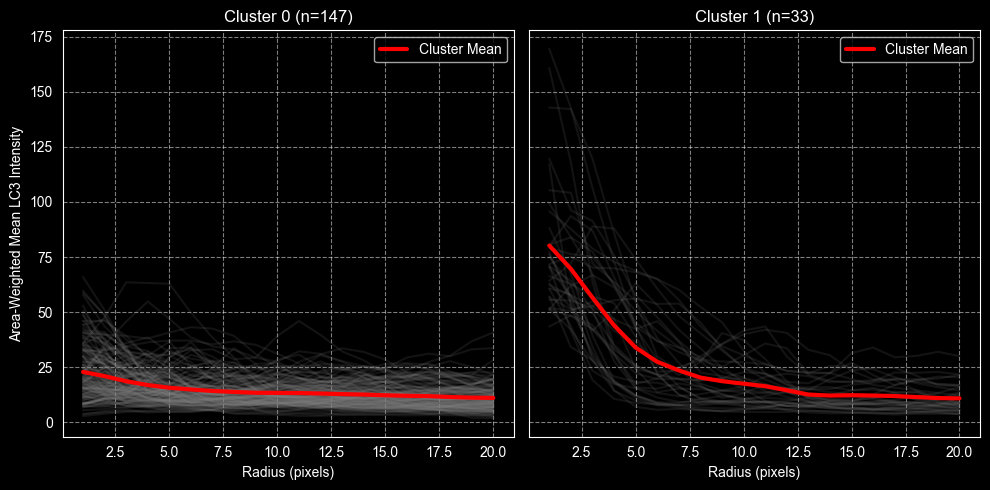

In [14]:
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)

for i in range(n_clusters):
    # Isolate the profiles belonging to the current cluster
    cluster_profiles = clean_matrix[cluster_labels == i]

    # Plot all individual profiles in this cluster faintly
    for prof in cluster_profiles:
        axes[i].plot(radii, prof, color="gray", alpha=0.15)

    # Calculate and plot the mean profile for this cluster
    if len(cluster_profiles) > 0:
        mean_prof = np.mean(cluster_profiles, axis=0)
        axes[i].plot(radii, mean_prof, color="red", linewidth=3, label="Cluster Mean")

    axes[i].set_title(f"Cluster {i} (n={len(cluster_profiles)})")
    axes[i].set_xlabel("Radius (pixels)")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    if i == 0:
        axes[i].set_ylabel("Area-Weighted Mean LC3 Intensity")
    axes[i].legend()

plt.tight_layout()

In [15]:
crop_size = 25  # 25 px in all directions = 50x50px crop
output_base = Path("./Outputs")


def rgb_from_lc3_and_mav(lc3: np.ndarray, mav: np.ndarray, brightfield: np.ndarray):
    """Create RGB from LC3, MAV, and brightfield image

    Brightfield is shown as grayscale. MAV is shown in green. MAV is shown in magenta.
    (By adding it in both the Red and Blue channel in equal parts.)

    Parameters:
        lc3 (np.ndarray): LC3 image
        mav (np.ndarray): MAV image
        brightfield (np.ndarray): Brightfield image

    Todo:
        Do color conversion by lookup table rather than hardcoded.

    """

    bf_norm = exposure.rescale_intensity(brightfield, out_range=(0.0, 1.0))
    lc3_norm = exposure.rescale_intensity(lc3, out_range=(0.0, 1.0))
    mav_norm = exposure.rescale_intensity(mav, out_range=(0.0, 1.0))

    r = np.clip((bf_norm * 0.5) + mav_norm, 0, 1)
    g = np.clip((bf_norm * 0.5) + lc3_norm, 0, 1)
    b = np.clip((bf_norm * 0.5) + mav_norm, 0, 1)

    return np.dstack((r, g, b))


global_rgb = rgb_from_lc3_and_mav(channel_lc3, channel_mav, channel_brightfield)
img_h, img_w = global_rgb.shape[:2]

print(f"Generating ROI plots for {len(cluster_labels)} blobs...")

for i, cluster_id in enumerate(cluster_labels):
    blob_idx = valid_blob_indices[i]
    cx = int(x_coords[blob_idx])
    cy = int(y_coords[blob_idx])
    profile = clean_matrix[i]

    cluster_dir = output_base / f"Cluster_{cluster_id}"
    cluster_dir.mkdir(parents=True, exist_ok=True)

    y_min, y_max = cy - crop_size, cy + crop_size
    x_min, x_max = cx - crop_size, cx + crop_size

    pad_top = max(0, -y_min)
    pad_bottom = max(0, y_max - img_h)
    pad_left = max(0, -x_min)
    pad_right = max(0, x_max - img_w)

    y_min_safe, y_max_safe = max(0, y_min), min(img_h, y_max)
    x_min_safe, x_max_safe = max(0, x_min), min(img_w, x_max)

    roi_rgb = global_rgb[y_min_safe:y_max_safe, x_min_safe:x_max_safe]

    if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
        roi_rgb = np.pad(
            roi_rgb,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="constant",
        )

    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [3, 1]}
    )

    # Left Plot: 50x50 RGB Composite
    axes[0].imshow(roi_rgb)
    axes[0].set_title(f"Blob {blob_idx} | MAV: Magenta, LC3: Green")
    axes[0].axis("off")

    # Add a subtle crosshair to the exact center of the crop
    axes[0].plot(
        crop_size, crop_size, marker="+", color="white", markersize=10, alpha=0.7
    )

    axes[1].plot(radii, profile, color="red", linewidth=2)
    axes[1].set_title("LC3 Profile")
    axes[1].set_xlabel("Radius (px)")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.suptitle(f"Cluster {cluster_id}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    save_path = cluster_dir / f"Cluster_{cluster_id}_blob_{blob_idx}_roi.jpg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.close(fig)  # Close the figure, otherwise these stay open in Jupyter

print(f"Successfully saved all ROIs to {output_base.absolute()}")

Generating ROI plots for 180 blobs...
Successfully saved all ROIs to /Users/twh/PycharmProjects/lc3_colocalization/Outputs
